In [1]:
from pathlib import Path
import requests

def download_from_github(rel_path, out=None):
    github_raw_base = (  # Base URL
        "https://raw.githubusercontent.com/rasbt/"
        "reasoning-from-scratch/refs/heads/main/"
    )
    rel_path = Path(rel_path)
    out = Path(out) if out is not None else Path(rel_path.name)
    if out.exists():
        size_kb = out.stat().st_size / 1e3
        print(f"{out}: {size_kb:.1f} KB (cached)")
        return out

    # Download file
    r = requests.get(github_raw_base + rel_path.as_posix())
    r.raise_for_status()

    out.write_bytes(r.content)
    size_kb = out.stat().st_size / 1e3
    print(f"{out}: {size_kb:.1f} KB")

In [2]:
download_from_github(
    "ch06/02_rlvr_grpo_scripts_intro/rlvr_grpo_original_no_kl.py"
)

rlvr_grpo_original_no_kl.py: 15.6 KB (cached)


PosixPath('rlvr_grpo_original_no_kl.py')

In [3]:
# Log file in plain text

download_from_github(
    "ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.txt"
)

# Same log file in CSV format
download_from_github(
    "ch07/02_logs/ch06_rlvr_grpo_original_no_kl_metrics.csv"
)

ch06_rlvr_grpo_original_no_kl_metrics.txt: 43.7 KB (cached)
ch06_rlvr_grpo_original_no_kl_metrics.csv: 25.1 KB (cached)


PosixPath('ch06_rlvr_grpo_original_no_kl_metrics.csv')

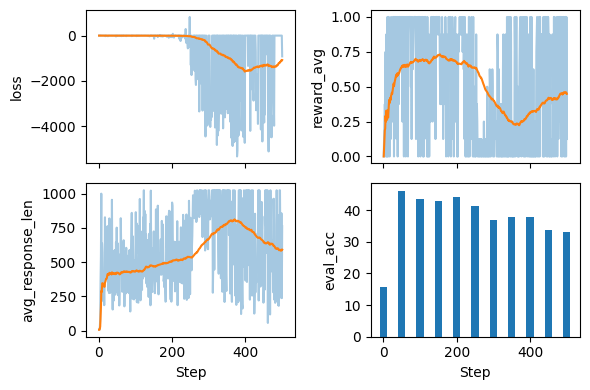

In [4]:
import csv, matplotlib.pyplot as plt

def moving_average(values, window_fraction=0.25):
    # Smooth a noisy training signal to reveal longer-term trends during training
    window_size = max(1, int(window_fraction * len(values)))
    smoothed = []

    for i in range(len(values)):
        start_idx = max(0, i - window_size + 1)
        window_mean = sum(values[start_idx : i + 1]) / (i - start_idx + 1)
        smoothed.append(window_mean)

    return smoothed

def plot_grpo_metrics(csv_path, columns, save_as=None):
    data = {name: {"steps": [], "values": []} for name in columns}

    # Open and read CSV log file
    with Path(csv_path).open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row or not row.get("step"):
                continue

            # Use the training step as the shared x-axis across all metrics
            step = int(row["step"])

            for name in columns:
                value_str = row.get(name)
                if value_str:
                    data[name]["steps"].append(step)
                    data[name]["values"].append(float(value_str))

    # Create a fixed grid so loss, rewards, response length, etc. can be shown side by side
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(6, 4))
    axes = axes.ravel()

    for i, name in enumerate(columns):
        steps = data[name]["steps"]
        values = data[name]["values"]

        # Skip metrics that are not present
        if not values:
            fig.delaxes(axes[i])
            continue

        # Evaluation accuracy as barplot because we don't have data for each step
        if name == "eval_acc":
            axes[i].bar(steps, values, width=20)
        else:
            axes[i].plot(steps, values, alpha=0.4)
            axes[i].plot(steps, moving_average(values))

        axes[i].set_ylabel(name)

    for j in (2, 3):
        if axes[j] in fig.axes:
            axes[j].set_xlabel("Step")

    plt.tight_layout()
    if save_as is not None:
        plt.savefig(save_as)
    plt.show()


# Plot the GRPO training run
plot_grpo_metrics(
    "ch06_rlvr_grpo_original_no_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    # save_as="4.pdf"
)

In [5]:
download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_math500.py"
)

evaluate_math500.py: 3.5 KB (cached)


PosixPath('evaluate_math500.py')

In [6]:
import torch

def compute_advantage_stats(rewards_list):
    rewards = torch.tensor(rewards_list)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    # These are the new statistics we add:
    adv_avg = advantages.mean().item()
    adv_std = advantages.std().item()

    return advantages, adv_avg, adv_std

In [7]:
adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 0., 0.])

print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([ 0.8659,  0.8659, -0.8659, -0.8659])
Advantage mean = 0.0000, std = 0.9998


In [8]:
adv, adv_avg, adv_std = compute_advantage_stats([1., 1., 1., 1.])
print(f"Advantages: {adv}")
print(f"Advantage mean = {adv_avg:.4f}, std = {adv_std:.4f}")

Advantages: tensor([0., 0., 0., 0.])
Advantage mean = 0.0000, std = 0.0000


In [9]:
logits = torch.tensor([
    0.6667, -2.0000,  1.3333, -0.0000, -0.6667,  2.0000, -1.3333
])

In [10]:
logprobs = torch.log_softmax(logits, dim=-1)
print("All token logprobs:", logprobs)

# Index of the selected token
selected_token = torch.argmax(logprobs)

selected = logprobs[selected_token]
print("Selected token ID:", selected_token)
print("Selected token logprob:", selected)

All token logprobs: tensor([-2.0442, -4.7109, -1.3776, -2.7109, -3.3776, -0.7109, -4.0442])
Selected token ID: tensor(5)
Selected token logprob: tensor(-0.7109)


In [11]:
# Probabilities from logits
probs = torch.softmax(logits, dim=-1)
logprobs = torch.log_softmax(logits, dim=-1)

# Entropy from probabilities
entropy = torch.sum(-(probs * logprobs))

print("Probs:", probs)
print("Entropy:", entropy)

Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])
Entropy: tensor(1.3700)


In [12]:
print("Probs:", torch.exp(logprobs))

Probs: tensor([0.1295, 0.0090, 0.2522, 0.0665, 0.0341, 0.4912, 0.0175])


In [13]:
def sequeunce_logprob_and_entropy(model, token_ids, prompt_len):
    logits = model(token_ids.unsqueeze(0)).squeeze(0).float()
    logprobs = torch.log_softmax(logits, dim=-1)

    targets = token_ids[1:]
    selected = logprobs[:-1].gather(1, targets.unsqueeze(-1)).squeeze(-1)

    selected_answer_logprobs = selected[prompt_len - 1:]
    logp_all_steps = torch.sum(selected_answer_logprobs)

    all_answer_logprobs = logprobs[:-1][prompt_len - 1:]
    if all_answer_logprobs.numel() == 0:  # Safeguard if the model immediately returns EOS token
        entropy_all_steps = logp_all_steps.new_tensor(0.0)
    else:
        all_answer_probs = torch.exp(all_answer_logprobs)  # convert logprob to prob
        plogp = all_answer_probs * all_answer_logprobs     # elementwise p * log p
        step_entropy = -torch.sum(plogp, dim=-1)           # sum over vocab -> entropy per step
        entropy_all_steps = torch.mean(step_entropy)       # average over answer steps

    return logp_all_steps, entropy_all_steps
    # For example, if we consider the answer "this is the LLM response", the step entropy is the entropy of one token (like "this"), 
    # and the average entropy over all answer steps is the average entropy over all answer tokens "this is the LLM response"

In [14]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_3_plus_tracking.py"
)

7_3_plus_tracking.py: 16.9 KB (cached)


PosixPath('7_3_plus_tracking.py')

In [15]:
download_from_github(
    "ch07/02_logs/7_3_plus_tracking_metrics.csv"
)

7_3_plus_tracking_metrics.csv: 39.0 KB (cached)


PosixPath('7_3_plus_tracking_metrics.csv')

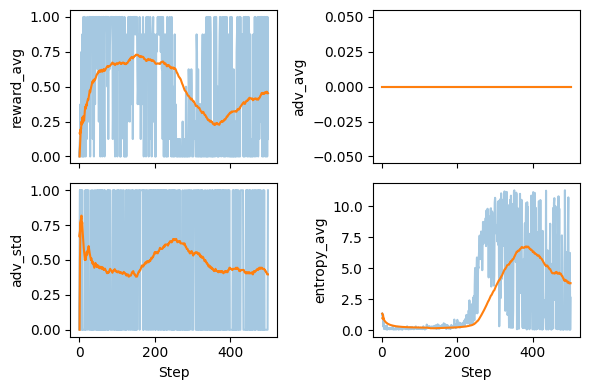

In [16]:
plot_grpo_metrics(
    "7_3_plus_tracking_metrics.csv",
    columns=["reward_avg", "adv_avg", "adv_std", "entropy_avg"],
    # save_as="9.pdf"
)

In [17]:
# in naive

rewards = torch.tensor([1., 1., 0., 0.])

# Compute sequence logprobs
logprobs = torch.tensor([-7.9243, -20.1546, -16.6130, -23.3677])

advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

pg_loss = -(advantages.detach() * logprobs).mean()
print("Policy gradient loss:", pg_loss)

Policy gradient loss: tensor(-2.5764)


In [18]:
new_logps = logprobs

# The values of the new_logps
# are shown side by side in the comments
old_logps = torch.tensor([
    -10.9243,   # -7.9243
    -20.3546,   # -20.1546
    -14.6130,   # -16.6130
    -23.3677,   # -23.3677
])

log_ratio = new_logps - old_logps
ratio = torch.exp(log_ratio)
clip_eps = 10.0
clipped_ratio = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps)

print("Ratio:        ", ratio)
print("Clipped ratio:", clipped_ratio)

Ratio:         tensor([20.0855,  1.2214,  0.1353,  1.0000])
Clipped ratio: tensor([11.0000,  1.2214,  0.1353,  1.0000])


In [19]:
adv = advantages.detach()

unclipped = ratio * adv
clipped = clipped_ratio * adv

obj = torch.where(
    adv >= 0,
    torch.minimum(unclipped, clipped),  # cap large positive updates
    torch.maximum(unclipped, clipped),  # cap large negative updates
)
    
clipped_pg_loss = -torch.mean(obj)
policy_ratio = torch.mean(ratio)

print("Clipped policy gradient loss:", clipped_pg_loss)
print("Policy ratio:", policy_ratio)

Clipped policy gradient loss: tensor(-2.3998)
Policy ratio: tensor(5.6106)


In [20]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_4_plus_clip_ratio.py"
)

7_4_plus_clip_ratio.py: 19.1 KB (cached)


PosixPath('7_4_plus_clip_ratio.py')

In [21]:
download_from_github(
    "ch07/02_logs/7_4_plus_clip_ratio_metrics.csv",
)

7_4_plus_clip_ratio_metrics.csv: 42.7 KB (cached)


PosixPath('7_4_plus_clip_ratio_metrics.csv')

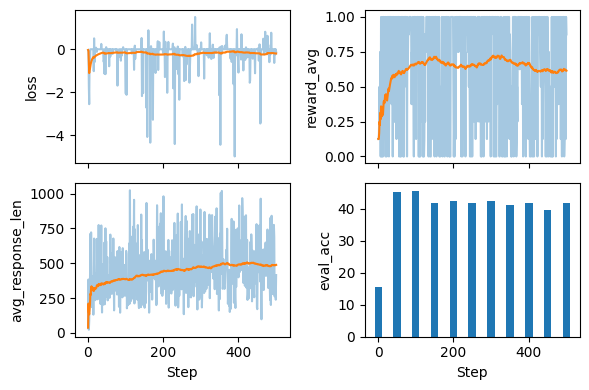

In [22]:
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    save_as="13_1.pdf"
)

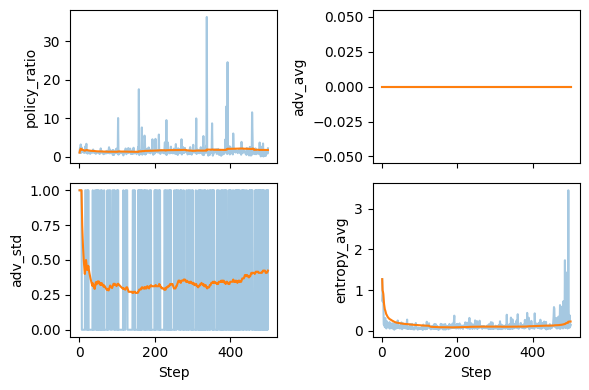

In [23]:
plot_grpo_metrics(
    "7_4_plus_clip_ratio_metrics.csv",
    columns=["policy_ratio", "adv_avg", "adv_std", "entropy_avg"],
    save_as="13_2.pdf"
)

In [24]:
import copy

kl_coeff = 0.0

if kl_coeff:
    ref_model = copy.deepcopy(model).to(device)
    ref_model.eval()
    for p in ref_model.parameters():
        p.requires_grad = False
else:
    ref_model = None

def compute_grpo_loss_with_kl(model, ref_model, tokenizer, example, device, num_rollouts=2, max_new_tokens=256, temperature=0.8, top_p=0.9, kl_coeff=0.02):
    assert num_rollouts >= 2
    roll_logps, roll_ref_logps, roll_rewards, samples = [],  [], [], []
    prompt = render_prompt(example['problem'])
    was_training = model.training
    model.eval()

    for _ in range(num_rollouts):
        token_ids, prompt_len, text = sample_response(model=model, tokenizer=tokenizer, prompt=prompt, device=device, max_new_tokens=max_new_tokens,
                                                        temperature=temperature, top_p=top_p)

        if kl_coeff:
            with torch.no_grad():
                ref_logp = sequence_logprob(ref_model, token_ids, prompt_len)
        else:
            ref_logp = None

        reward = reward_rlvr(text, example["answer"])

        roll_logps.append(logp)
        roll_rewards.append(reward)

        if kl_coeff:
            roll_ref_logps.append(ref_logp)

        samples.append(
            {
                "text": text,
                "reward": reward,
                "gen_len": token_ids.numel() - prompt_len,
            }
        )
    if was_training:
        model.train()

    rewards = torch.tensor(roll_rewards, device=device)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)
    logps = torch.stack(roll_logps)

    if kl_coeff:
        ref_logps = torch.stack(roll_ref_logps).detach()

    pg_loss = -(advantages.detach() * logps).mean()

    if kl_coeff:
        kl_loss = kl_coeff * torch.mean(logps - ref_logps)
    else:
        kl_loss = torch.tensor(0.0, device=logps.device)

    loss = pg_loss + kl_loss

    return {
        "loss": loss.item(),
        "pg_loss": pg_loss.item(),
        "rewards": roll_rewards,
        "advantages": advantages.detach().cpu().tolist(),
        "samples": samples,
        "loss_tensor": loss,
    }  

In [25]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_5_plus_kl.py"
)

7_5_plus_kl.py: 20.8 KB (cached)


PosixPath('7_5_plus_kl.py')

In [26]:
download_from_github(
    "ch07/02_logs/"
    "7_5_plus_kl_metrics.csv"
)

7_5_plus_kl_metrics.csv: 48.8 KB (cached)


PosixPath('7_5_plus_kl_metrics.csv')

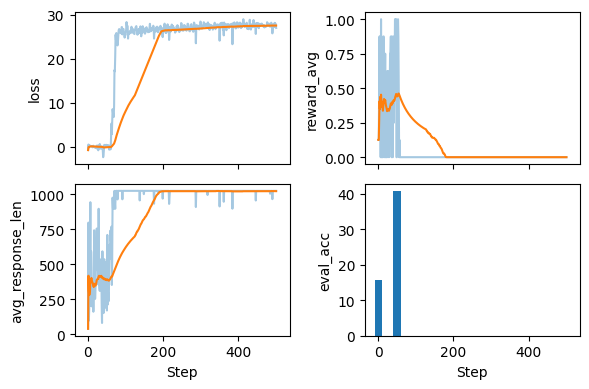

In [27]:
plot_grpo_metrics(
    "7_5_plus_kl_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    # save_as="16.pdf"
)

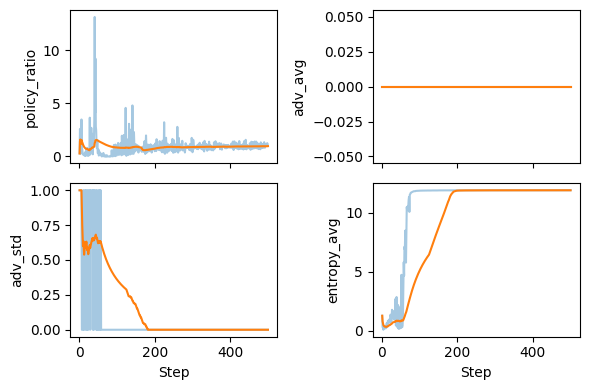

In [28]:
plot_grpo_metrics(
    "7_5_plus_kl_metrics.csv",
    columns=["policy_ratio", "adv_avg", "adv_std", "entropy_avg"],
)

In [29]:
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import load_model_and_tokenizer

device = get_device()
model, tokenizer_base = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using CPU
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [30]:
print(tokenizer_base.encode("<think>"))

[13708, 766, 29]


In [31]:
for i in [13708, 766, 29]:
    print(tokenizer_base.decode([i]))

<th
ink
>


In [32]:
tokenizer_base._tok.add_special_tokens(
    ["<tool_response>", "</tool_response>", "<think>", "</think>"]
)

4

In [33]:
print(tokenizer_base.encode("<think>"))

[151667]


In [34]:
print(tokenizer_base.encode("</think>"))

[151668]


In [35]:
print("Vocabulary size:", model.tok_emb.weight.shape[0])

Vocabulary size: 151936


In [36]:
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer
from reasoning_from_scratch.qwen3 import download_qwen3_small

download_qwen3_small(
    kind="reasoning", tokenizer_only=True, out_dir="qwen3"
)

tokenizer_path = Path("qwen3") / "tokenizer-reasoning.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

✓ qwen3/tokenizer-reasoning.json already up-to-date


In [37]:
print(tokenizer.encode("<think>"))
print(tokenizer.encode("</think>"))

[151667]
[151668]


In [39]:
def reward_format(token_ids, prompt_len, start_think_id=151667, end_think_id=151668):
    try:
        gen = token_ids[prompt_len:].tolist()
        return float(gen.index(start_think_id) < gen.index(end_think_id))
    except ValueError:
        return 0.0

In [40]:
prompt = "Calculate ..."
rollout = "Let's ... <think> ... </think> ..."
token_ids = tokenizer.encode(prompt + rollout)

reward_format(
    token_ids=torch.tensor(token_ids),
    prompt_len=len(tokenizer.encode(prompt))
)

1.0

In [41]:
def compute_grpo_loss(model, tokenizer, example, device, num_rollouts=2, max_new_tokens=256, temperature=0.8, top_p=0.9, format_reward_weight=1.0):
    assert num_rollouts >= 2
    roll_logps, roll_rewards, samples = [],  [], []
    prompt = render_prompt(example['problem'])
    was_training = model.training
    model.eval()

    for _ in range(num_rollouts):
        token_ids, prompt_len, text = sample_response(model=model, tokenizer=tokenizer, prompt=prompt, device=device, max_new_tokens=max_new_tokens,
                                                        temperature=temperature, top_p=top_p)
        logp = sequence_logprob(model, token_ids, prompt_len)
        rlvr_reward = reward_rlvr(text, example["answer"])
        format_reward = reward_format(token_ids, prompt_len)
        reward = rlvr_reward + format_reward_weight*format_reward

        roll_logps.append(logp)
        roll_rewards.append(reward)
        samples.append(
            {
                "text": text,
                "reward": reward,
                "gen_len": token_ids.numel() - prompt_len,
            }
        )
    if was_training:
        model.train()

    rewards = torch.tensor(roll_rewards, device=device)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)
    logps = torch.stack(roll_logps)
    pg_loss = -(advantages.detach() * logps).mean()
    loss = pg_loss

    return {
        "loss": loss.item(),
        "pg_loss": pg_loss.item(),
        "rewards": roll_rewards,
        "advantages": advantages.detach().cpu().tolist(),
        "samples": samples,
        "loss_tensor": loss,
    }  

In [42]:
def render_prompt_with_think_tokens(prompt):
    template = (
        "You are a helpful math assistant.\n"
        "When solving the problem, first write your reasoning inside <think> and </think> tags.\n"
        "Then write the final result on a new line in the exact format:\n"
        "\\boxed{ANSWER}\n\n"
        f"Question:\n{prompt}\n\nAnswer:"
    )
    return template

In [43]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_6_plus_format_reward.py"
)

7_6_plus_format_reward.py: 23.1 KB


In [44]:
download_from_github(
    "ch07/02_logs/7_6_plus_format_reward_metrics.csv"
)

7_6_plus_format_reward_metrics.csv: 51.7 KB


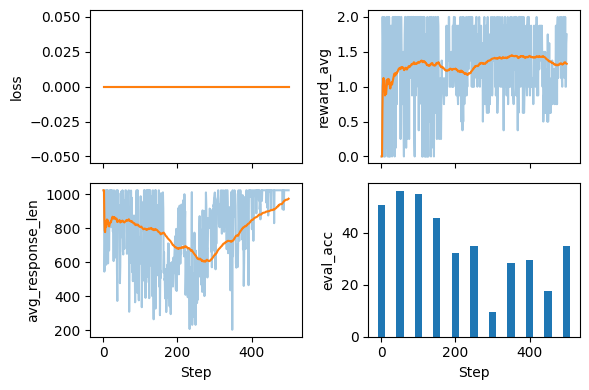

In [45]:
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    #save_as="18.pdf"
)

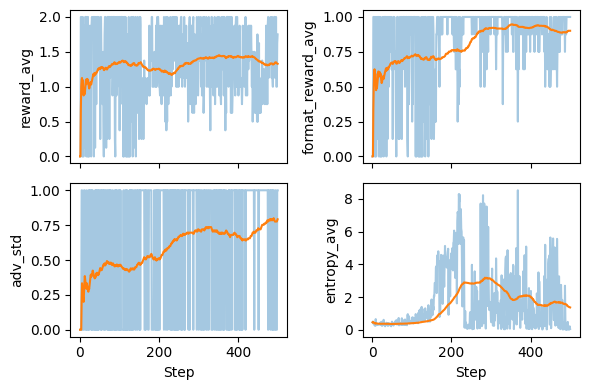

In [46]:
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["reward_avg", "format_reward_avg", "adv_std", "entropy_avg"],
    #save_as="19.pdf"
)